In [1]:
import os
import pandas as pd
import numpy as np
import multiprocess as mp
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from itertools import combinations
from MetabolicWorkers import process_single_task

# Section 1: Calculate Error Values from Multiple Excel Test Files

##### Configuration

In [2]:
DATA_FOLDER = r'Data\RTA_OMNIA_Auto'
VT1_OUTPUT_FILE = "vt1_error_values.csv"
VT2_OUTPUT_FILE = "vt2_error_values.csv"

# Configurations to test (X_Axis, Y_Axis, which_vt)
VT1_TEST_CONFIGURATIONS = [
    ("V-Slope", None, 'vt1'),
    ("VO2", "VCO2", 'vt1'),
    ("VO2", "VE/VO2", 'vt1'),
    ("VO2", "PetO2", 'vt1'),
    ("VO2", "excess_co2", 'vt1'),
    ("RQ=", 0.85, 'vt1'),
    ("high_rer_mask", 1.0, 'vt1'),
    ("fat_max_mask", None, 'vt1')
]

VT2_TEST_CONFIGURATIONS = [
    ("VO2", "VE/VCO2", 'vt2'),
    ("VO2", "PetCO2", 'vt2'),
    ("RQ=", 1.0, 'vt2'),
    ("VO2", "excess_Ve", 'vt2')
]

##### Process Tests

In [3]:
def batch_process_parallel(folder_path, test_configurations, output_csv):
    files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    tasks = [(os.path.join(folder_path, f), conf, f) for f in files for conf in test_configurations]

    print(f"Spinning up {mp.cpu_count()} workers...")
    
    # Multiprocess
    with mp.Pool(processes=mp.cpu_count()) as pool:
        results_of_lists = pool.map(process_single_task, tasks)
        
    all_results = [item for sublist in results_of_lists for item in sublist]
    final_df = pd.DataFrame(all_results)
    final_df.to_csv(output_csv, index=False)
    
    return final_df
    
# Process VT1
print("\n" + "="*30)
print("VT1 BATCH PROCESSING BEGIN") 
print("="*30)
print()
    
vt1_results = batch_process_parallel(DATA_FOLDER, VT1_TEST_CONFIGURATIONS, VT1_OUTPUT_FILE)
#vt1_results = None
if vt1_results is not None:
    print("\n" + "="*30)
    print("VT1 BATCH PROCESSING COMPLETE")
    print(f"Trials Processed: {len(vt1_results)}")
    print(f"Results saved to: {VT1_OUTPUT_FILE}")
    print("="*30)

# Process VT2
print("\n" + "="*30)
print("VT2 BATCH PROCESSING BEGIN") 
print("="*30)
print()

vt2_results = batch_process_parallel(DATA_FOLDER, VT2_TEST_CONFIGURATIONS, VT2_OUTPUT_FILE)
#vt2_results = None
if vt2_results is not None:
    print("\n" + "="*30)
    print("VT2 BATCH PROCESSING COMPLETE")
    print(f"Trials Processed: {len(vt2_results)}")
    print(f"Results saved to: {VT2_OUTPUT_FILE}")
    print("="*30)



VT1 BATCH PROCESSING BEGIN

Spinning up 24 workers...

VT1 BATCH PROCESSING COMPLETE
Trials Processed: 9552
Results saved to: vt1_error_values.csv

VT2 BATCH PROCESSING BEGIN

Spinning up 24 workers...

VT2 BATCH PROCESSING COMPLETE
Trials Processed: 5996
Results saved to: vt2_error_values.csv


# Section 2: Process All VT1 Combinations

##### Configuration

In [4]:
true_values = {
    "01 01 20260116 CPET BxB_20260210095828.xlsx": 1.931, "02 02 20260123 CPET BxB_20260210095834.xlsx": 1.735,
    "03 03 20250213 CPET BxB_20260210095838.xlsx": 1.564, "04 04 20260115 CPET BxB_20260210095833.xlsx": 1.428,
    "05 05 20260126 CPET BxB_20260210095829.xlsx": 1.344, "06 06 20260127 CPET BxB_20260210095833.xlsx": 2.807,
    "07 07 20260114 CPET BxB_20260210095835.xlsx": 2.504, "08 08 20260126 CPET BxB_20260210095839.xlsx": 1.309,
    "09 09 20260127 CPET BxB_20260210095826.xlsx": 1.234, "10 10 20260128 CPET BxB_20260210095831.xlsx": 1.478,
    "11 11 20260114 CPET BxB_20260210095836.xlsx": 1.085, "12 12 20260116 CPET BxB_20260210095838.xlsx": 1.574,
    "13 13 20260121 CPET BxB_20260210095830.xlsx": 1.360, "14 14 20260204 CPET BxB_20260210095837.xlsx": 1.677,
    "15 15 20260204 CPET BxB_20260210095826.xlsx": 1.814, "16 16 20260121 CPET BxB_20260210095832.xlsx": 1.812,
    "17 17 20260126 CPET BxB_20260210095836.xlsx": 1.142, "18 18 20260126 CPET BxB_20260210095834.xlsx": 1.679,
    "19 19 20170929 CPET BxB_20260210095832.xlsx": 2.975, "20 20 20250422 CPET BxB_20260210095849.xlsx": 2.659,
    "21 21 20140130 CPET BxB_20260210095840.xlsx": 2.372, "22 22 20160204 CPET BxB_20260210095826.xlsx": 3.275,
    "23 23 20160307 CPET BxB_20260210095839.xlsx": 2.267, "24 24 20260126 CPET BxB_20260210095827.xlsx": 1.558,
    "25 25 20160210 CPET BxB_20260210095828.xlsx": 1.966, "26 26 20260126 CPET BxB_20260210095833.xlsx": 3.152,
    "27 27 20250826 CPET BxB_20260210095835.xlsx": 2.532, "28 28 20160208 CPET BxB_20260210095837.xlsx": 2.468,
    "29 29 20220502 CPET BxB_20260210095830.xlsx": 2.297, "30 30 20250808 CPET BxB_20260210095831.xlsx": 1.531,
    "31 31 20250825 CPET BxB_20260210095827.xlsx": 2.904, "32 32 20250630 CPET BxB_20260210095829.xlsx": 1.669
}

methods = [
    "V-Slope",
    "VCO2_vs_VO2",
    "VE/VO2_vs_VO2",
    "PetO2_vs_VO2",
    "excess_co2_vs_VO2",
    "RQ=0.85",
    "High_RER_1.0_Mask",
    "FatMax_Mask",
]

##### Run all combinations

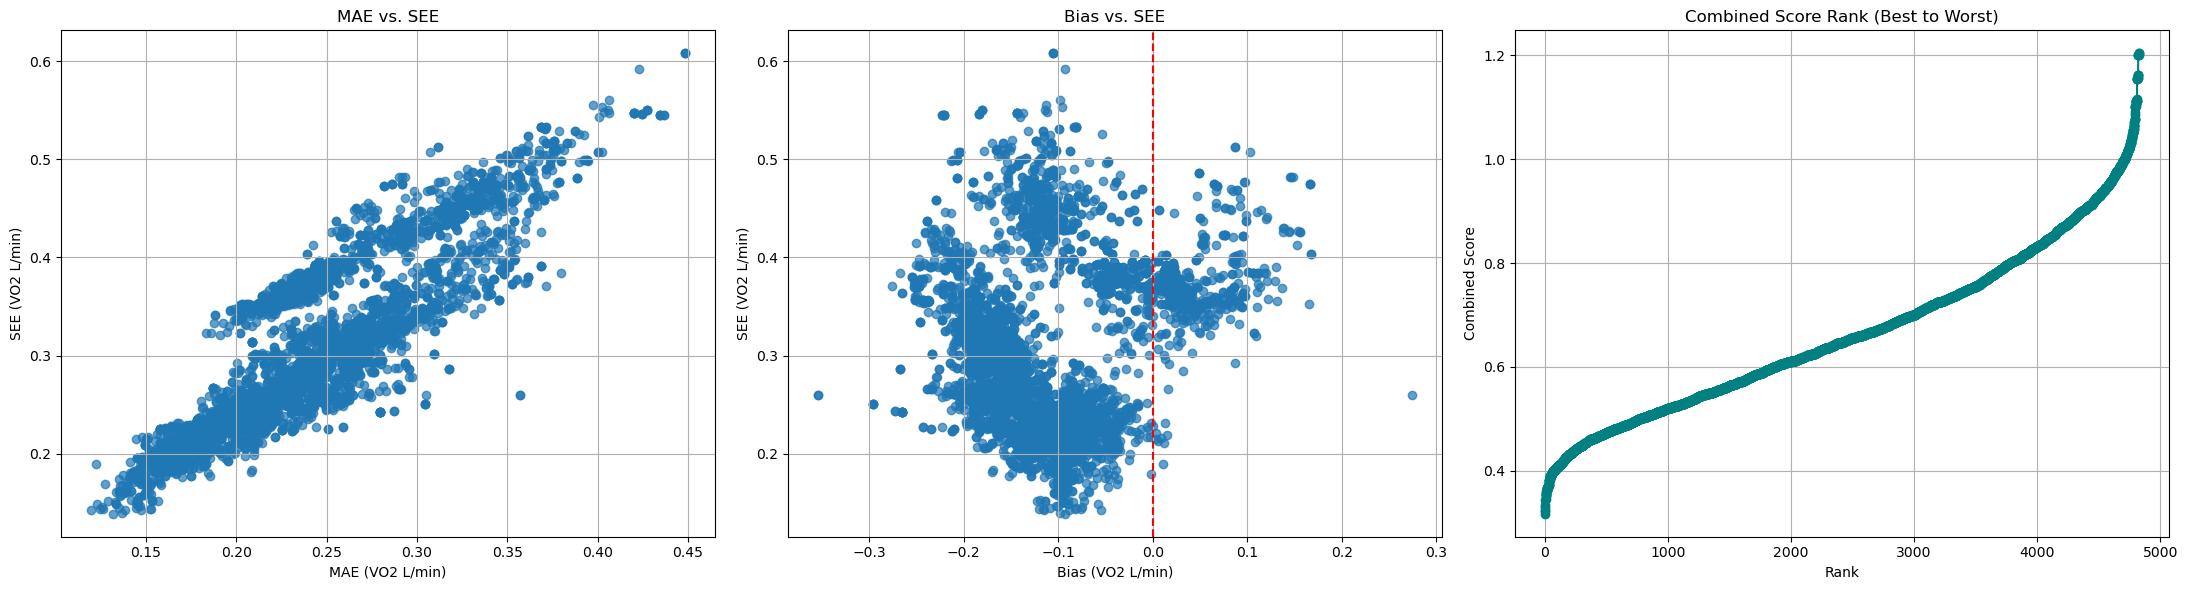

,Strategy,Smoothing_Scope,Combination,Methods_Used,MAE,Mean_Error,SEE,Combined_Score
0,Rolling 7pt,Both,V-Slope + VE/VO2 + excess + RQ=0.85 + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ...",0.119577,-0.054804,0.143018,0.317400
1,Gaussian 2.0,Both,High + FatMax,"[High_RER_1.0_Mask, FatMax_Mask]",0.122538,0.010405,0.189688,0.322631
2,Rolling 7pt,Both,VE/VO2 + High + FatMax,"[VE/VO2_vs_VO2, High_RER_1.0_Mask, FatMax_Mask]",0.141577,-0.002277,0.179790,0.323645
3,Rolling 7pt,Both,V-Slope + VE/VO2 + excess + RQ=0.85 + High + F...,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, RQ...",0.122804,-0.058032,0.148739,0.329575
4,Gaussian 2.0,Both,excess + FatMax,"[excess_co2_vs_VO2, FatMax_Mask]",0.127183,-0.037499,0.168978,0.333660
5,Rolling 7pt,Both,V-Slope + VCO2 + VE/VO2 + excess + RQ=0.85 + H...,"[V-Slope, VCO2_vs_VO2, VE/VO2_vs_VO2, excess_c...",0.124615,-0.075775,0.143806,0.344195
6,Rolling 7pt,Both,V-Slope + VCO2 + VE/VO2 + excess + RQ=0.85 + F...,"[V-Slope, VCO2_vs_VO2, VE/VO2_vs_VO2, excess_c...",0.125527,-0.074863,0.145592,0.345982
7,Rolling 7pt,Both,V-Slope + VE/VO2 + excess + High + FatMax,"[V-Slope, VE/VO2_vs_VO2, excess_co2_vs_VO2, Hi...",0.138896,-0.047856,0.165682,0.352434
8,Rolling 7pt,Both,V-Slope + PetO2 + excess + RQ=0.85 + High + Fa...,"[V-Slope, PetO2_vs_VO2, excess_co2_vs_VO2, RQ=...",0.126434,-0.082491,0.144029,0.352954
9,Rolling 7pt,Both,V-Slope + PetO2 + excess + RQ=0.85 + FatMax,"[V-Slope, PetO2_vs_VO2, excess_co2_vs_VO2, RQ=...",0.128666,-0.073173,0.151422,0.353260


In [5]:
# LOAD & PREPARE DATA
df_raw = pd.read_csv('vt1_error_values.csv')
df = df_raw.pivot(index=['FileName', 'Time', 'VO2'], columns='Method', values='Normalized_Error').reset_index()
df.columns.name = None

# --- 1. CONFIGURATION ---
# Define the base smoothing tasks (Type, Value, Label)
base_tasks = [
    ('none', 0, 'No Smoothing'),
    ('rolling', 3, 'Rolling 3pt'),
    ('rolling', 5, 'Rolling 5pt'),
    ('rolling', 7, 'Rolling 7pt'),
    ('gaussian', 0.25, 'Gaussian 0.25'),
    ('gaussian', 0.5,  'Gaussian 0.5'),
    ('gaussian', 0.6,  'Gaussian 0.6'),
    ('gaussian', 0.8,  'Gaussian 0.8'),
    ('gaussian', 1.0,  'Gaussian 1.0'),
    ('gaussian', 2.0,  'Gaussian 2.0')
]

all_test_results = []

# --- 2. OUTERMOST LOOP: SCOPE (Both vs. Average Only) ---
for smooth_both in [True, False]:
    scope_label = "Both" if smooth_both else "Avg Only"
    
    # --- 3. MIDDLE LOOP: SMOOTHING STRATEGY ---
    for s_type, s_val, s_label in base_tasks:
        
        # Skip 'none' for the True/False loop to avoid redundant 'No Smoothing' results
        if s_type == 'none' and smooth_both is False:
            continue

        for r in range(1, len(methods) + 1):
            for combo in combinations(methods, r):
                combo_list = list(combo)
                
                # Fresh copy for this specific pass
                temp_df = df[['FileName', 'VO2'] + combo_list].copy()
                
                # --- 4. OPTIONAL: SMOOTH INDIVIDUAL COLUMNS ---
                if smooth_both and s_type != 'none':
                    for col in combo_list:
                        if s_type == 'rolling':
                            temp_df[col] = temp_df.groupby('FileName')[col].transform(
                                lambda x: x.rolling(window=s_val, center=True).mean().combine_first(x)
                            )
                        elif s_type == 'gaussian':
                            temp_df[col] = temp_df.groupby('FileName')[col].transform(
                                lambda x: gaussian_filter1d(x, sigma=s_val)
                            )

                # --- CALCULATE AVERAGE ---
                temp_df['Temp_Average'] = temp_df[combo_list].mean(axis=1, skipna=True)
                
                # --- ALWAYS SMOOTH THE FINAL AVERAGE (If not 'none') ---
                if s_type != 'none':
                    if s_type == 'rolling':
                        temp_df['Temp_Average'] = temp_df.groupby('FileName')['Temp_Average'].transform(
                            lambda x: x.rolling(window=s_val, center=True).mean().combine_first(x)
                        )
                    elif s_type == 'gaussian':
                        temp_df['Temp_Average'] = temp_df.groupby('FileName')['Temp_Average'].transform(
                            lambda x: gaussian_filter1d(x, sigma=s_val)
                        )

                # --- 7. SELECTION & ERROR CALCULATION ---
                best_indices = temp_df.groupby('FileName')['Temp_Average'].idxmin()
                df_selections = temp_df.loc[best_indices].copy()
                df_selections['True_VO2'] = df_selections['FileName'].map(true_values)
                
                df_selections['Error'] = df_selections['VO2'] - df_selections['True_VO2']
                df_selections['Abs_Error'] = df_selections['Error'].abs()
                
                all_test_results.append({
                    "Strategy": s_label,
                    "Smoothing_Scope": scope_label,
                    "Combination": " + ".join([m.split('_')[0] for m in combo_list]),
                    "Methods_Used": combo_list,
                    "MAE": df_selections['Abs_Error'].mean(),
                    "Mean_Error": df_selections['Error'].mean(),
                    "SEE": df_selections['Error'].std()
                })

# --- RESULTS SUMMARY ---
results_df_original = pd.DataFrame(all_test_results)
results_df_original['Combined_Score'] = results_df_original['MAE'] + results_df_original['Mean_Error'].abs() + results_df_original['SEE']
results_df_original = results_df_original.sort_values('Combined_Score').reset_index(drop=True)
results_df = results_df_original.copy()

# Optional: Hide outliers
results_df = results_df[results_df['Combined_Score'] < 1.25].copy()

# VISUALIZATION
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# MAE vs SEE
scatter1 = ax1.scatter(results_df['MAE'], results_df['SEE'], alpha=0.7)
ax1.set_title('MAE vs. SEE')
ax1.set_xlabel('MAE (VO2 L/min)'); ax1.set_ylabel('SEE (VO2 L/min)'); ax1.grid(True)

# Bias vs SEE
scatter2 = ax2.scatter(results_df['Mean_Error'], results_df['SEE'], alpha=0.7)
ax2.axvline(0, color='red', linestyle='--'); ax2.set_title('Bias vs. SEE')
ax2.set_xlabel('Bias (VO2 L/min)'); ax2.set_ylabel('SEE (VO2 L/min)'); ax2.grid(True)

# Score Rank
ax3.plot(results_df.index, results_df['Combined_Score'], marker='o', color='teal')
ax3.set_title('Combined Score Rank (Best to Worst)')
ax3.set_xlabel('Rank'); ax3.set_ylabel('Combined Score'); ax3.grid(True)

plt.tight_layout()
#plt.savefig("vt1_performance_results.png", dpi=300, bbox_inches='tight')
plt.show()

results_df = results_df_original

# SAVE
results_df.to_csv("vt1_ranked_combinations.csv", index=False)
display(results_df.head(30))

##### Get Average Rankings

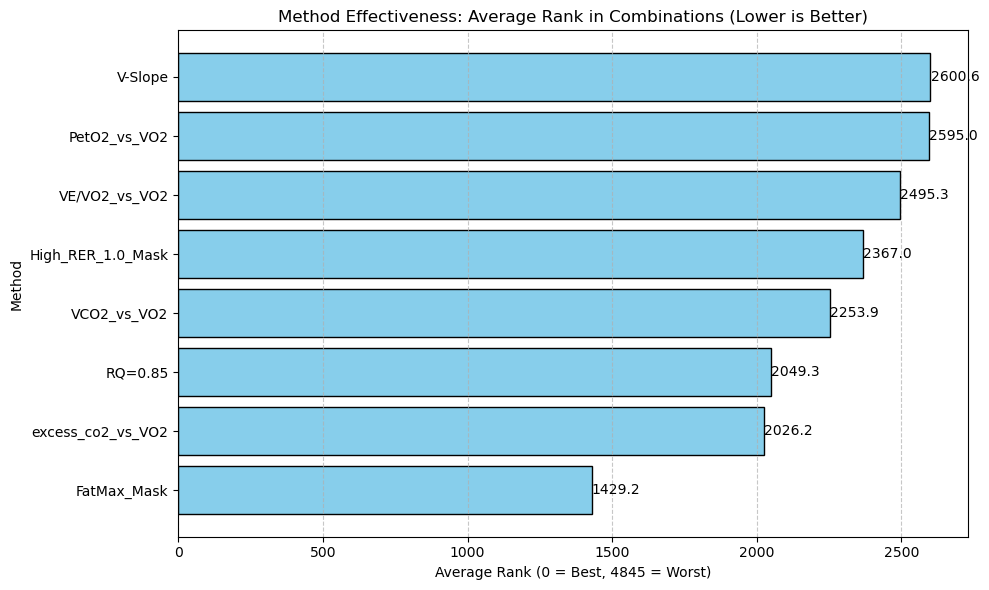

--- Average Rank per Method ---


,Average_Rank
FatMax_Mask,1429.181743
excess_co2_vs_VO2,2026.189556
RQ=0.85,2049.275493
VCO2_vs_VO2,2253.873766
High_RER_1.0_Mask,2367.009868
VE/VO2_vs_VO2,2495.295641
PetO2_vs_VO2,2595.013980
V-Slope,2600.620477


In [6]:
# CALCULATE AVERAGE RANK FOR EACH METHOD
method_ranks = {m: [] for m in methods}

# results_df is assumed to be sorted by Combined_Score (best to worst)
for idx, row in results_df.iterrows():
    for method in row['Methods_Used']:
        method_ranks[method].append(idx)

# Create a summary dataframe of average ranks
avg_rank_df = pd.DataFrame({m: np.mean(ranks) for m, ranks in method_ranks.items()}, index=['Average_Rank']).T
avg_rank_df = avg_rank_df.sort_values(by='Average_Rank')

# Plot effectiveness
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_rank_df.index, avg_rank_df['Average_Rank'], color='skyblue', edgecolor='black')

# Labeling
plt.title('Method Effectiveness: Average Rank in Combinations (Lower is Better)')
plt.xlabel(f'Average Rank (0 = Best, {len(results_df)} = Worst)')
plt.ylabel('Method')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}', va='center')

plt.tight_layout()
plt.show()

# Display the numerical table
print("--- Average Rank per Method ---")
display(avg_rank_df)

# Section 3: Get VT1 Selections For a Set of Excel Tests 

##### Load Data

In [7]:
df = pd.read_csv('vt1_error_values.csv')

# index: columns to keep as they are
# columns: the values in this column become the new column headers
# values: the values that will fill the new columns
df = df.pivot(index=['FileName', 'Time', 'VO2'], columns='Method', values='Normalized_Error').reset_index()

# Remove the name of the columns index
df.columns.name = None

# Print method columns
METHOD_COLS = [col for col in df.columns if col not in ['FileName', 'Time', 'VO2']]
print("Available Method Columns:")
for method in METHOD_COLS:
    print(f'    {method}')

Available Method Columns:
    FatMax_Mask
    High_RER_1.0_Mask
    PetO2_vs_VO2
    RQ=0.85
    V-Slope
    VCO2_vs_VO2
    VE/VO2_vs_VO2
    excess_co2_vs_VO2


##### Configuration

In [8]:
SMOOTH_METHOD = True
SMOOTH_AVERAGE = True
FILTER_TYPE = 'gaussian'  # Options: 'none', 'rolling' or 'gaussian'
WINDOW_SIZE = 1           # Number of data points for the window/sigma
# List of specific columns to include in the average
COLS_TO_AVERAGE = [
    "FatMax_Mask",
    "High_RER_1.0_Mask",
    "excess_co2_vs_VO2",
    #"Ve/VO2_vs_VO2",
    "VCO2_vs_VO2",
    #"V-Slope",
    "RQ=0.85"
]

##### Smooth and Average Data

In [9]:
def smooth_data(series, filter_type, window_size):
    if filter_type == 'none':
        return series
    elif filter_type == 'rolling':
        return series.rolling(window=window_size, center=True, min_periods=1).mean()
    elif filter_type == 'gaussian':
        return gaussian_filter1d(series, sigma=window_size)
    return series

# -------------------------------------------------------
# Smooth Method Columns
# -------------------------------------------------------
if SMOOTH_METHOD:
    cols_to_smooth = [col for col in METHOD_COLS if "Mask" not in col]

    if cols_to_smooth:
        # Apply the chosen filter per FileName
        df[cols_to_smooth] = df.groupby('FileName')[cols_to_smooth].transform(smooth_data, filter_type=FILTER_TYPE, window_size=WINDOW_SIZE)
        print(f"Filter applied to method columns: {FILTER_TYPE} (window/sigma: {WINDOW_SIZE})")

    cols_skipped = [col for col in METHOD_COLS if "Mask" in col]
    if cols_skipped:
        print(f"Skipped smoothing for: {', '.join(cols_skipped)}")

# -------------------------------------------------------
# Average Chosen Methods
# -------------------------------------------------------
# Calculate the row-wise (axis=1) average
df['Average'] = df[COLS_TO_AVERAGE].mean(axis=1)

print("Average calculated using columns:")
for c in COLS_TO_AVERAGE:
    print(f'    {c}')
print()

# -------------------------------------------------------
# Smooth average column
# -------------------------------------------------------
if SMOOTH_AVERAGE:
    df["Average"] = df.groupby('FileName')["Average"].transform(smooth_data, filter_type=FILTER_TYPE, window_size=WINDOW_SIZE)
    
    print(f"Filter applied to average column: {FILTER_TYPE} (window/sigma: {WINDOW_SIZE})")

Filter applied to method columns: gaussian (window/sigma: 1)
Skipped smoothing for: FatMax_Mask, High_RER_1.0_Mask
Average calculated using columns:
    FatMax_Mask
    High_RER_1.0_Mask
    excess_co2_vs_VO2
    VCO2_vs_VO2
    RQ=0.85

Filter applied to average column: gaussian (window/sigma: 1)


##### Create Plots

In [10]:
# --- SETTINGS ---
COLUMNS_TO_PLOT = COLS_TO_AVERAGE.copy()
COLUMNS_TO_PLOT.append("Average")
output_folder = "VT1_Plots"

# Create the folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

# Get all unique filenames
all_files = df['FileName'].unique()

print(f"Starting batch plot for {len(all_files)} files...")

for file_name in all_files:
    subset = df[df['FileName'] == file_name]
    
    # Skip if subset is somehow empty
    if subset.empty:
        continue
        
    plt.figure(figsize=(12, 7))
    
    # Loop through each column and plot it
    for col in COLUMNS_TO_PLOT:
        if col == "Average":
            plt.plot(subset['VO2'], subset[col], label=col, linewidth=2, marker='o', markersize=2.5, alpha=0.75)
        else:    
            plt.plot(subset['VO2'], subset[col], label=col, linewidth=0.5, marker='o', markersize=1, alpha=0.25)
    
    # --- Threshold Detection Logic ---
    if "Average" in subset.columns:
        min_err_idx = subset['Average'].idxmin()
        get_vo2 = subset.loc[min_err_idx, 'VO2']
        
        plt.axvline(x=get_vo2, color='red', linestyle='--', 
                    label=f'Min Average Error ({get_vo2:.3f} L/min)')
    
    # Adding titles and labels
    plt.title(f"VT1 Error vs. $VO_2$\nFile: {file_name}", fontsize=14)
    plt.xlabel("$VO_2$ (L/min)", fontsize=12)
    plt.ylabel("Normalized Error", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Replace characters that might break file paths (like .xlsx) with underscores
    clean_filename = str(file_name).replace('.', '_')
    
    # Save the plot
    save_path = os.path.join(output_folder, f"{clean_filename}_vt1.png")
    plt.savefig(save_path, dpi=150)
    plt.close()

print(f"Done! All plots have been saved to the '{output_folder}' folder.")

Starting batch plot for 32 files...
Done! All plots have been saved to the 'VT1_Plots' folder.


##### Get Results for Each File

In [11]:
# Find the index of the minimum 'Average' for each FileName
best_indices = df.groupby('FileName')['Average'].idxmin()

# Use those indices to pull the full rows from the original dataframe
# Only select the following columns: FileName, Time, and VO2
df_best_points = df.loc[best_indices, ['FileName', 'Time', 'VO2']].copy().reset_index(drop=True)

# Print results
print("--- Summary of Best VT1 Threshold Points ---")
display(df_best_points)

# Save results
df_best_points.to_csv("vt1_threshold_points.csv", index=False)

--- Summary of Best VT1 Threshold Points ---


,FileName,Time,VO2
0,01 01 20260116 CPET BxB_20260210095828.xlsx,00:06:27,1.403933
1,02 02 20260123 CPET BxB_20260210095834.xlsx,00:07:48,1.749666
2,03 03 20250213 CPET BxB_20260210095838.xlsx,00:06:53,1.441816
3,04 04 20260115 CPET BxB_20260210095833.xlsx,00:05:47,1.278215
4,05 05 20260126 CPET BxB_20260210095829.xlsx,00:08:14,1.189968
5,06 06 20260127 CPET BxB_20260210095833.xlsx,00:07:09,2.637260
6,07 07 20260114 CPET BxB_20260210095835.xlsx,00:08:06,2.503824
7,08 08 20260126 CPET BxB_20260210095839.xlsx,00:07:14,1.112234
8,09 09 20260127 CPET BxB_20260210095826.xlsx,00:06:34,1.011190
9,10 10 20260128 CPET BxB_20260210095831.xlsx,00:08:06,1.225679


# Section 4: Get VT2 Selections For a Set of Excel Tests

##### Load Data

In [12]:
df = pd.read_csv('vt2_error_values.csv')

# index: columns to keep as they are
# columns: the values in this column become the new column headers
# values: the values that will fill the new columns
df = df.pivot(index=['FileName', 'Time', 'VO2', 'VCO2'], columns='Method', values='Normalized_Error').reset_index()

# Remove the name of the columns index
df.columns.name = None

# Print method columns
METHOD_COLS = [col for col in df.columns if col not in ['FileName', 'Time', 'VO2', 'VCO2']]
print("Available Method Columns:")
for method in METHOD_COLS:
    print(f'    {method}')

Available Method Columns:
    PetCO2_vs_VO2
    RQ=1.0
    VE/VCO2_vs_VO2
    excess_Ve_vs_VO2


##### Configuration

In [13]:
SMOOTH_METHOD = True
SMOOTH_AVERAGE = True
FILTER_TYPE = 'gaussian'  # Options: 'none', 'rolling' or 'gaussian'
WINDOW_SIZE = 1           # Number of data points for the window/sigma

# List of columns to include in the average
COLS_TO_AVERAGE = [
    "PetCO2_vs_VO2",
    "RQ=1.0",
    "VE/VCO2_vs_VO2",
    "excess_Ve_vs_VO2"
]

##### Smooth and Average Data

In [14]:
# -------------------------------------------------------
# Smooth Method Columns
# -------------------------------------------------------
if SMOOTH_METHOD:
    cols_to_smooth = [col for col in METHOD_COLS if "Mask" not in col]

    if cols_to_smooth:
        # Apply the chosen filter per FileName
        df[cols_to_smooth] = df.groupby('FileName')[cols_to_smooth].transform(smooth_data, filter_type=FILTER_TYPE, window_size=WINDOW_SIZE)
        print(f"Filter applied to method columns: {FILTER_TYPE} (window/sigma: {WINDOW_SIZE})")

    cols_skipped = [col for col in METHOD_COLS if "Mask" in col]
    if cols_skipped:
        print(f"Skipped smoothing for: {', '.join(cols_skipped)}")

# -------------------------------------------------------
# Average Chosen Methods
# -------------------------------------------------------
# Calculate the row-wise (axis=1) average
df['Average'] = df[COLS_TO_AVERAGE].mean(axis=1)

print("Average calculated using columns:")
for c in COLS_TO_AVERAGE:
    print(f'    {c}')
print()

# -------------------------------------------------------
# Smooth average column
# -------------------------------------------------------
if SMOOTH_AVERAGE:
    df["Average"] = df.groupby('FileName')["Average"].transform(smooth_data, filter_type=FILTER_TYPE, window_size=WINDOW_SIZE)
    
    print(f"Filter applied to average column: {FILTER_TYPE} (window/sigma: {WINDOW_SIZE})")

Filter applied to method columns: gaussian (window/sigma: 1)
Average calculated using columns:
    PetCO2_vs_VO2
    RQ=1.0
    VE/VCO2_vs_VO2
    excess_Ve_vs_VO2

Filter applied to average column: gaussian (window/sigma: 1)


##### Create Plots

In [15]:
# --- SETTINGS ---
COLUMNS_TO_PLOT = COLS_TO_AVERAGE.copy()
COLUMNS_TO_PLOT.append("Average")
output_folder = "VT2_Plots"

# Create the folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

# Get all unique filenames
all_files = df['FileName'].unique()

print(f"Starting batch plot for {len(all_files)} files...")

for file_name in all_files:
    subset = df[df['FileName'] == file_name]
    
    # Skip if subset is somehow empty
    if subset.empty:
        continue
        
    plt.figure(figsize=(12, 7))
    
    # Loop through each column and plot it
    for col in COLUMNS_TO_PLOT:
        if col == "Average":
            plt.plot(subset['VO2'], subset[col], label=col, linewidth=2, marker='o', markersize=2.5, alpha=0.75)
        else:    
            plt.plot(subset['VO2'], subset[col], label=col, linewidth=0.5, marker='o', markersize=1, alpha=0.25)
    
    # --- Threshold Detection Logic ---
    if "Average" in subset.columns:
        min_err_idx = subset['Average'].idxmin()
        get_vo2 = subset.loc[min_err_idx, 'VO2']
        
        plt.axvline(x=get_vo2, color='red', linestyle='--', 
                    label=f'Min Average Error ({get_vo2:.3f} L/min)')
    
    # Adding titles and labels
    plt.title(f"VT2 Error vs. $VO_2$\nFile: {file_name}", fontsize=14)
    plt.xlabel("$VO_2$ (L/min)", fontsize=12)
    plt.ylabel("Normalized Error", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Replace characters that might break file paths (like .xlsx) with underscores
    clean_filename = str(file_name).replace('.', '_')
    
    # Save the plot
    save_path = os.path.join(output_folder, f"{clean_filename}_vt2.png")
    plt.savefig(save_path, dpi=150)
    plt.close()

print(f"Done! All plots have been saved to the '{output_folder}' folder.")

Starting batch plot for 32 files...
Done! All plots have been saved to the 'VT2_Plots' folder.


##### Get Results for Each File

In [16]:
# Find the index of the minimum 'Average' for each FileName
best_indices = df.groupby('FileName')['Average'].idxmin()

# Use those indices to pull the full rows from the original dataframe
# Only select the following columns: FileName, Time, and VO2
df_best_points = df.loc[best_indices, ['FileName', 'Time', 'VO2']].copy().reset_index(drop=True)

# Print results
print("--- Summary of Best VT2 Threshold Points ---")
display(df_best_points)

# Save results
df_best_points.to_csv("vt2_threshold_points.csv", index=False)

--- Summary of Best VT2 Threshold Points ---


,FileName,Time,VO2
0,01 01 20260116 CPET BxB_20260210095828.xlsx,00:08:15,2.125837
1,02 02 20260123 CPET BxB_20260210095834.xlsx,00:04:40,1.277515
2,03 03 20250213 CPET BxB_20260210095838.xlsx,00:08:30,1.756375
3,04 04 20260115 CPET BxB_20260210095833.xlsx,00:08:07,1.632748
4,05 05 20260126 CPET BxB_20260210095829.xlsx,00:10:11,1.480504
5,06 06 20260127 CPET BxB_20260210095833.xlsx,00:07:30,2.742112
6,07 07 20260114 CPET BxB_20260210095835.xlsx,00:07:15,2.186011
7,08 08 20260126 CPET BxB_20260210095839.xlsx,00:08:20,1.240174
8,09 09 20260127 CPET BxB_20260210095826.xlsx,00:11:07,1.414150
9,10 10 20260128 CPET BxB_20260210095831.xlsx,00:10:30,1.715487
